In [1]:
# SPDX-License-Identifier: CC-BY-4.0
# Code for "Active Continual Learning with Metaplastic Binary Bayesian Neural Networks"
# Kellian Cottart, Théo Ballet, Djohan Bonnet, Damien Querlioz
# Portions of the code are adapted from the Pytorch project (BSD-3-Clause)
# Author: Kellian Cottart <kellian.cottart@gmail.com>
# Date: 2025-30-01

In [2]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
import re
import json
import pandas as pd
import numpy as np
AXESSIZE = 28
FONTSIZE = 26
TICKSIZE = 24   
LEGENDSIZE = 26
plt.rcParams['svg.fonttype'] = 'none'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.05"
results_folder = "results-main-openloris-al"
figures_folder = "figures-main-openloris-al"
os.makedirs(figures_folder, exist_ok=True)
df = pd.DataFrame()
# iterate through all root folders in the results folder
for folder in os.listdir(results_folder):
    current_path = os.path.join(results_folder, folder)
    # extract the name from the first config
    config_path = os.path.join(current_path, "config0/config.json")
    with open(config_path, "r") as f:
        config = json.load(f)
    # n_iterations is the number of config folders
    n_iterations = len([f for f in os.listdir(current_path) if f.startswith("config") and os.path.isdir(os.path.join(current_path, f))])
    
    # Add the row of parameters to the dataframe   
    def method_wrapper(config):
        if "active_learning" in config["network_params"]:
            if not "mode" in config["network_params"]["active_learning"]:
                return list(config["network_params"]["active_learning"].keys())[0]  
            else:
                mode_map = {
                    0: "Epistemic",
                    1: "Aleatoric",
                    2: "Predictive",
                    3: "VR",
                    4: "Random",
                    5: "VR-True"
                }
                return mode_map.get(config["network_params"]["active_learning"]["mode"], "Random")
        return "Random"
    
    # Add the row of parameters to the dataframe   
    field = [key for key in config.keys() if "ewc" in key]
    normalisation = config["task_params"].get("dataset_normalisation", "none")
    row = {
        "path": current_path,
        "opt": f"{config['optimizer']}-{normalisation}" if normalisation != "none" else config["optimizer"],
        "n_tasks": config["n_tasks"],
        "n_epochs": config["epochs"],
        "n_train_samples": config["n_train_samples"] if "n_train_samples" in config else 1,
        "n_test_samples": config["n_test_samples"] if "n_test_samples" in config else 1,
        "n_iterations": n_iterations,
        "batch_size": config["train_batch_size"],
        # key containing ewc but not strictly equal to ewc
        "ewc": config[field[0]] if len(field) > 0 else "none",
        "method": method_wrapper(config),
        "n_active_learning_samples": int(config["network_params"]["active_learning"]["samples"]) if "active_learning" in config["network_params"] and "samples" in config["network_params"]["active_learning"] else "none",
        "threshold": float(config["network_params"]["active_learning"]["threshold"]) if "active_learning" in config["network_params"] and "threshold" in config["network_params"]["active_learning"] else "none",
        "N": int(config["optimizer_params"]["N"]) if "N" in config["optimizer_params"] else "none",
        "interleaved": int(config["task_params"].get("interleaved", 0)),
        "n_splits_per_epoch": int(config.get("n_splits_per_epoch", 1)),
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    

In [3]:
df["opt"].unique()

array(['mesu', 'adamw', 'bimu', 'bayesbinn', 'mesu-standardised'],
      dtype=object)

In [4]:
data = []
for idx, row in df.iterrows():
    path = row["path"]
    n_tasks = row["n_tasks"]
    n_epochs = row["n_epochs"]
    n_iterations = row["n_iterations"]
    n_splits_per_epoch = row["n_splits_per_epoch"] if "n_splits_per_epoch" in row else 1
    full_accuracies = []
    full_updates = []
    final_updates = []
    full_wras = []
    full_uras = []
    # indexes_under_represented = np.load(
    # os.path.join(path, "config0", "indexes_under_represented.npy"),
    # allow_pickle=True
    # ).tolist()

    # indexes_well_represented = np.load(
    #     os.path.join(path, "config0", "indexes_well_represented.npy"),
    #     allow_pickle=True
    # ).tolist()
    full_per_class_acc = []
    for it in range(n_iterations):
        current_it_path = os.path.join(path, f"config{it}")
        accuracy_path = os.path.join(current_it_path, "accuracy")
        uncertainty_path = os.path.join(current_it_path, "uncertainty")
        accuracies = []
        updates = []
        wras = []
        uras = []
        class_accuracies = []
        for task in range(n_tasks):
            for epoch in range(n_epochs):
                for split in range(n_splits_per_epoch):
                    suffix = f"split={split}-task={task}-epoch={epoch}.npy"
                    accuracies.append(jnp.load(os.path.join(accuracy_path, suffix)))
                    updates.append(jnp.load(os.path.join(accuracy_path, "iterations-"+suffix)))
                    wras.append(jnp.load(os.path.join(accuracy_path, "wra-"+suffix)))
                    uras.append(jnp.load(os.path.join(accuracy_path, "ura-"+suffix)))
                    #class_accuracies.append(jnp.load(os.path.join(accuracy_path, "per-class-acc-"+suffix)))
        full_accuracies.append(jnp.array(accuracies))
        final_updates.append(jnp.load(os.path.join(current_it_path, "iterations.npy")))
        full_updates.append(jnp.array(updates))
        full_wras.append(jnp.array(wras))
        full_uras.append(jnp.array(uras))
        # full_per_class_acc.append(jnp.array(class_accuracies))

    full_accuracies = jnp.array(full_accuracies)*100
    full_wras = jnp.array(full_wras)*100
    full_uras = jnp.array(full_uras)*100
    full_updates = jnp.array(full_updates)
    final_updates = jnp.array(final_updates).mean()
    # data.append((full_updates, full_accuracies, final_updates, full_wras, full_uras, indexes_under_represented, indexes_well_represented, full_per_class_acc))
    data.append((full_updates, full_accuracies, final_updates, full_wras, full_uras))
    
# Add new columns to df
df["updates"] = [d[0] for d in data]
df["accuracies"] = [d[1] for d in data]
df["final_updates"] = [d[2] for d in data]
df["wras"] = [d[3] for d in data]
df["uras"] = [d[4] for d in data]
# df["indexes_under_represented"] = [d[5] for d in data]
# df["indexes_well_represented"] = [d[6] for d in data]
# df["per_class_acc"] = [d[7] for d in data]


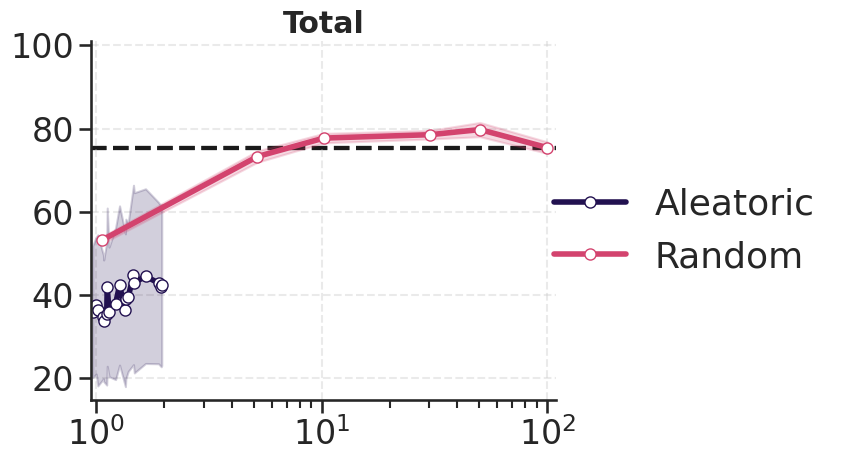

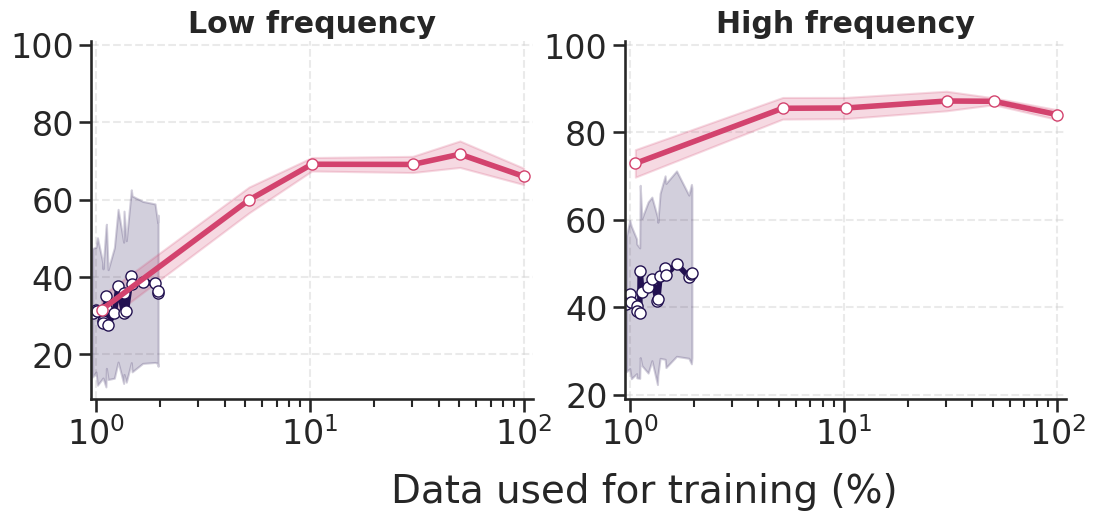

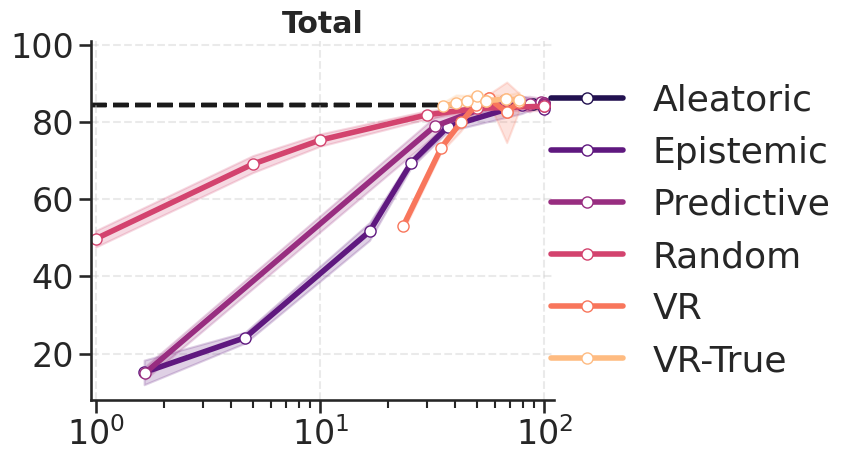

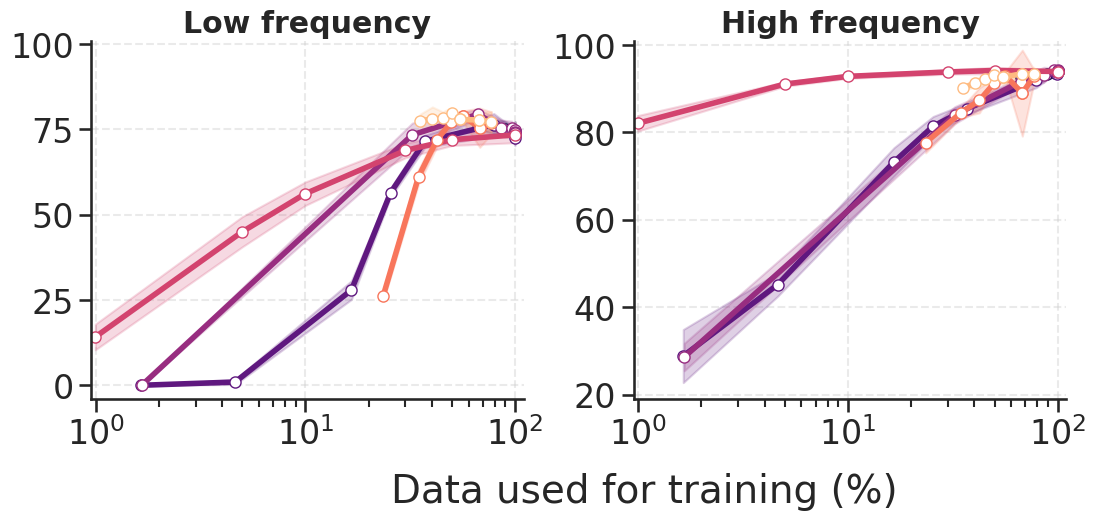

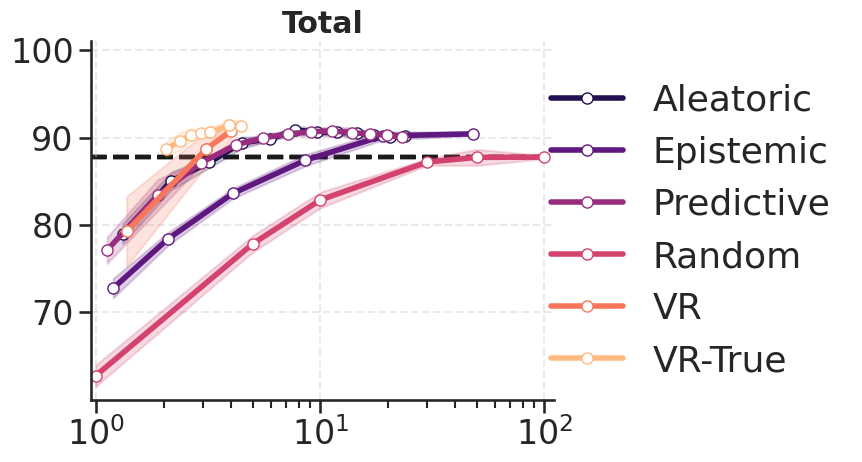

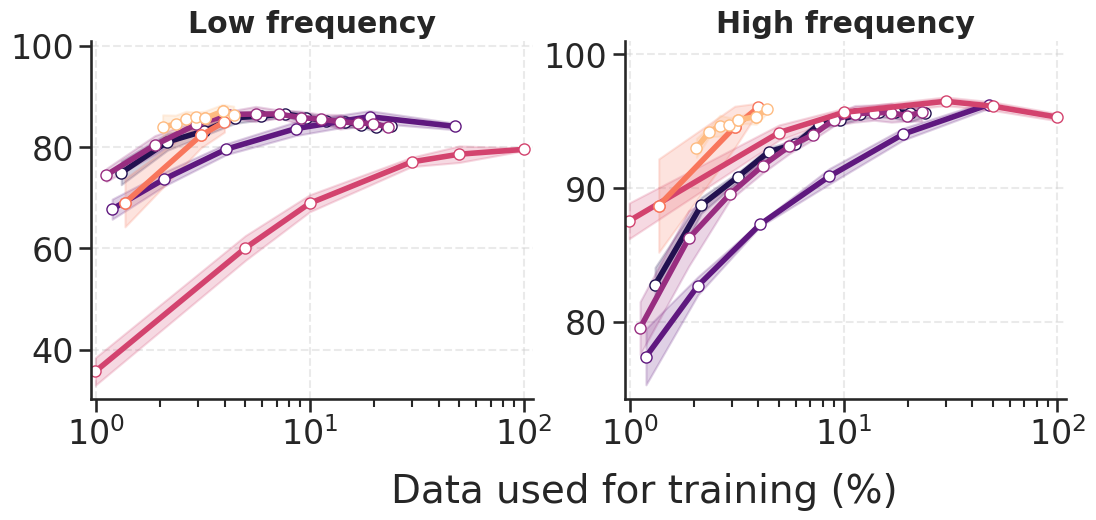

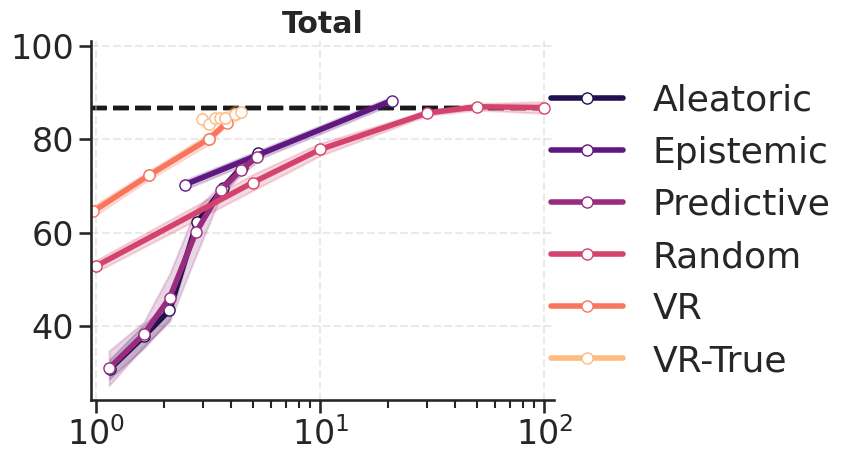

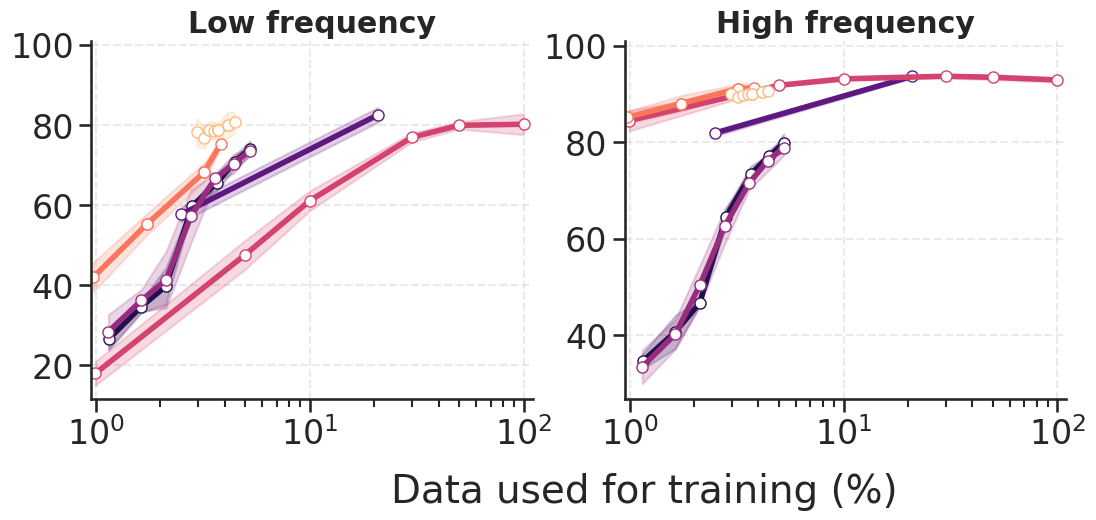

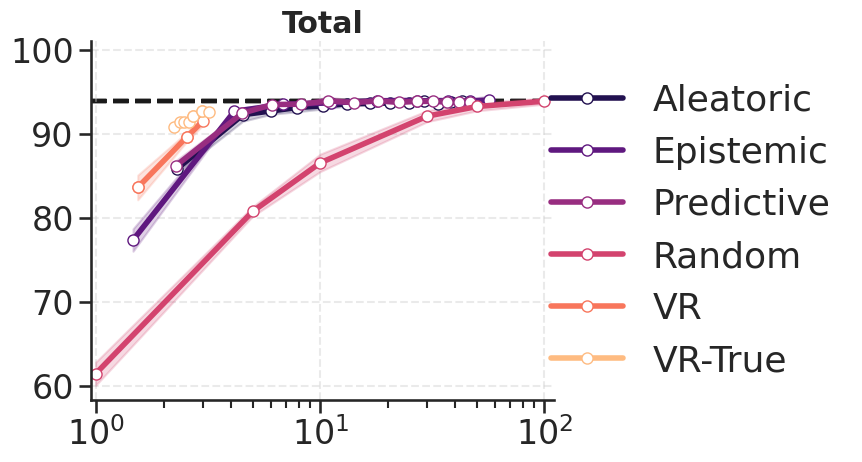

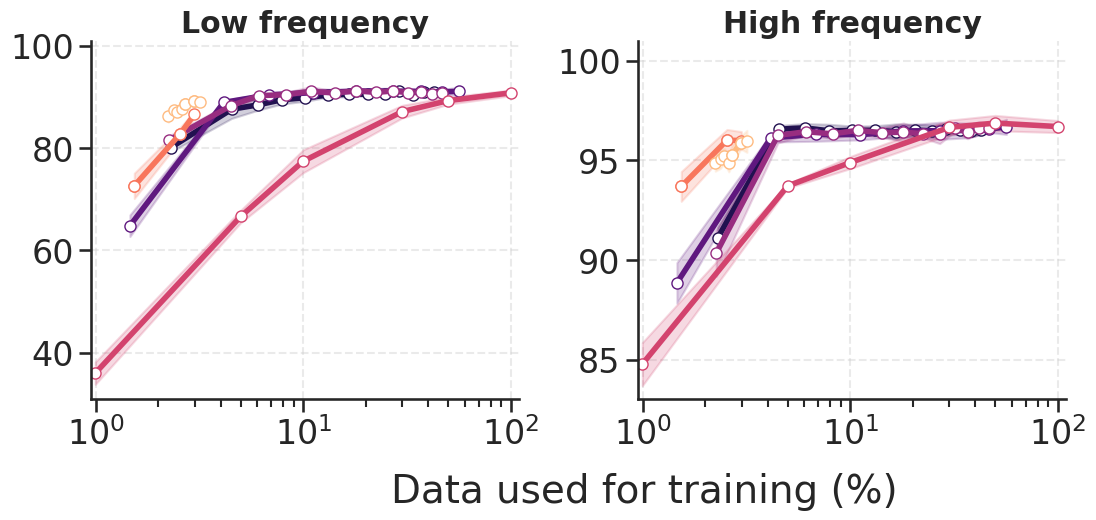

In [5]:

sns.set_theme(style="ticks", context="talk", font_scale=1.2)

order = ["Aleatoric", "Epistemic", "Predictive",  "Random", "VR", "VR-True"]
color_palette = sns.color_palette("magma", n_colors=len(order))
palette = {
    method: color_palette[i] for i, method in enumerate(order)
}


plt.rcParams.update({
    'svg.fonttype': 'none',
    'pdf.use14corefonts': True,
    'font.family': 'sans-serif',
    "font.sans-serif": ['Helvetica', 'Arial', 'DejaVu Sans', 'sans-serif']
})

hard_compression_limit = 0.95

def plot_with_ci(data, color, marker, **kwargs):
    plt.plot(
        data["Percentage"],
        data["Score"],
        color=color,
        lw=4,
        marker=marker,
        markersize=8,
        markerfacecolor='white',
        label=data["Method"].iloc[0],
    )
    plt.fill_between(
        data["Percentage"],
        data["Score"] - data["Std"],
        data["Score"] + data["Std"],
        color=color,
        alpha=0.2
    )
    
def plot_with_ci_and_baseline(data, color, marker, baseline_acc, **kwargs):
    plt.axhline(
        y=baseline_acc,
        color='k',
        linestyle='--',
        lw=3,
        alpha=1,
        zorder=-1,
        label="Target"
    )
    # plt.text(
    #     y=baseline_acc + 4,
    #     x=1,
    #     s=f"Target: {baseline_acc:.2f}%",
    #     fontsize=FONTSIZE,
    #     color='k'
    # )
    plot_with_ci(data, color, marker, **kwargs)

def style_axes(g):
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
        ax.set_ylim(None, 101)
        ax.xaxis.set_minor_locator(
            plt.LogLocator(base=10.0, subs=jnp.arange(1, 10.0))
        )
        ax.set_xlim(hard_compression_limit, 110)
        sns.despine(ax=ax)

for opt, optimizers_df in df.sort_values("final_updates").groupby("opt"):
    plot_data = []

    for method, group_df in optimizers_df.groupby("method"):
        for _, row in group_df.iterrows():
            
            
            max_ex = optimizers_df["final_updates"].max()

            percentage = float(row["final_updates"]) / float(max_ex) * 100
            if percentage < hard_compression_limit:
                continue

            plot_data.append({
                "Method": method,
                "Percentage": percentage,
                "Total": float(row["accuracies"].mean(-1).mean(0)[-1]),
                "Low frequency": float(row["uras"].mean(0)[-1]),
                "High frequency": float(row["wras"].mean(0)[-1]),
                "Total_std": float(row["accuracies"].mean(-1).std(0)[-1]),
                "Low frequency_std": float(row["uras"].std(0)[-1]),
                "High frequency_std": float(row["wras"].std(0)[-1]),
            })

    plot_df = pd.DataFrame(plot_data)
    plot_df_long = plot_df.melt(
        id_vars=["Method", "Percentage"],
        value_vars=["Total", "Low frequency", "High frequency"],
        var_name="Metric",
        value_name="Score"
    )
    std_df = plot_df.melt(
        id_vars=["Method", "Percentage"],
        value_vars=["Total_std", "Low frequency_std", "High frequency_std"],
        var_name="Metric_std",
        value_name="Std"
    )
    plot_df_long["Std"] = std_df["Std"]
    total_df = plot_df_long[plot_df_long["Metric"] == "Total"]
    freq_df  = plot_df_long[plot_df_long["Metric"] != "Total"]
    baseline_acc = (
        total_df[total_df["Percentage"] == 100.0]["Score"].max()
    )
    g_total = sns.FacetGrid(
        total_df,
        col="Metric",
        hue="Method",
        palette=palette,
        height=5,
        aspect=1.2,
        sharey=False
    )
    g_total.map_dataframe(
        plot_with_ci_and_baseline,
        marker="o",
        baseline_acc=baseline_acc
    )
    style_axes(g_total)
    g_total.add_legend(frameon=False, fontsize=LEGENDSIZE)
    g_total._legend.set_title(None)
    g_total.set_titles("{col_name}", fontweight="bold", fontsize=AXESSIZE)

    plt.savefig(os.path.join(figures_folder, f"openloris-{opt}-total.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(figures_folder, f"openloris-{opt}-total.svg"), bbox_inches='tight')
    plt.show()

    g_freq = sns.FacetGrid(
        freq_df,
        col="Metric",
        hue="Method",
        palette=palette,
        height=5,
        aspect=1.1,
        sharey=False
    )
    g_freq.map_dataframe(
        plot_with_ci,
        marker="o"
    )

    style_axes(g_freq)
    g_freq.set_titles("{col_name}", fontweight="bold", fontsize=AXESSIZE)
    g_freq.fig.text(0.35, -0.05, "Data used for training (%)", fontsize=AXESSIZE)
    plt.savefig(os.path.join(figures_folder, f"openloris-{opt}-frequency.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(figures_folder, f"openloris-{opt}-frequency.svg"), bbox_inches='tight')
    plt.show()


/tmp/ipykernel_805084/1025906797.py:65: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


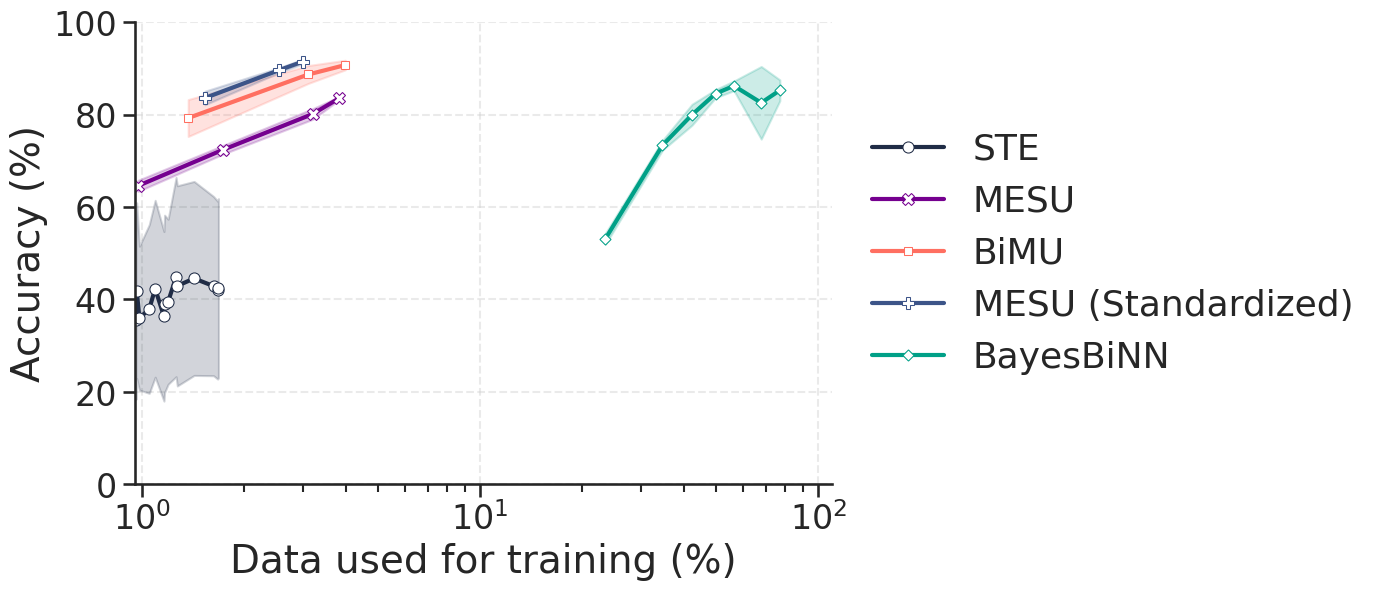

In [6]:
# === FILTER TO FAIR COMPARISON ===
compare_df = df[df["method"] == "VR"].copy()
ste_df = df[(df["method"] == "Aleatoric") & (df["opt"] == "adamw")].copy()
ste_df["opt"] = "STE"
compare_df = pd.concat([compare_df, ste_df], ignore_index=True)

rename_map = {
    "STE": "STE",
    "mesu": "MESU",
    "mesu-standardised": "MESU (Standardized)",
    "bimu": "BiMU",
    "bayesbinn": "BayesBiNN",
}
# Rename the opts
compare_df["opt"] = compare_df["opt"].map(rename_map)
colors = {
    "STE": "#202C46",
    "MESU": "#75008F",
    "MESU (Standardized)": "#3C5488",
    "BiMU": "#FF6F61",
    "BayesBiNN": "#00A087",
}

def build_accuracy_curve(df, max_ex):
    rows = []
    std_rows = []
    for _, row in df.iterrows():
        pct = row["final_updates"] / max_ex * 100
        if pct >= hard_compression_limit:
            rows.append({
                "Model": row["opt"],
                "Pct": pct.item(),
                "Accuracy": row["accuracies"].mean(-1).mean(0)[-1].item(),
                "Std": row["accuracies"].mean(-1).std(0)[-1].item(),
            })
    return pd.DataFrame(rows)

curve_df = build_accuracy_curve(compare_df, max_ex).sort_values("Pct")
plt.figure(figsize=(9,6))




ax = sns.lineplot(
    data=curve_df,
    x="Pct",
    y="Accuracy",
    hue="Model",    
    palette=colors,
    lw=3,
    style="Model",
    markers=True,
    dashes=False,
    markersize=8,
)


for line in ax.lines:
    line.set_markerfacecolor("white")
    line.set_markeredgecolor(line.get_color())

# also fix legend marker faces
leg = ax.get_legend()
if leg is not None:
    for lh in leg.legendHandles:
        try:
            lh.set_markerfacecolor("white")
            lh.set_markeredgecolor(lh.get_color())
        except Exception:
            pass

for model in compare_df["opt"].unique():
    model_data = curve_df[curve_df["Model"] == model]
    plt.fill_between(
        model_data["Pct"],
        model_data["Accuracy"] - model_data["Std"],
        model_data["Accuracy"] + model_data["Std"],
        alpha=0.2,
        color=colors[model]
    )

plt.xscale("log")
plt.xlabel("Data used for training (%)", fontsize=AXESSIZE)
plt.ylabel("Accuracy (%)", fontsize=AXESSIZE)
plt.grid(True, ls="--", alpha=0.4)
plt.xticks(fontsize=TICKSIZE)
plt.yticks(fontsize=TICKSIZE)
sns.despine()
plt.ylim(0, 100)
plt.xlim(hard_compression_limit, 110)
plt.legend(frameon=False, fontsize=LEGENDSIZE, bbox_to_anchor=(1.01, 0.5), loc='center left')
plt.savefig(os.path.join(figures_folder, "openloris-vr-comparison.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(figures_folder, "openloris-vr-comparison.svg"), bbox_inches='tight')
plt.show()
